### CELL 1: Import

In [1]:
!pip install pandas numpy matplotlib scikit-learn imbalanced-learn lightgbm xgboost

In [2]:
# ================================================================
# CELL 1: Import
# ================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV          # [FIX 7]
from sklearn.metrics import (
    classification_report, f1_score, roc_auc_score,
    precision_recall_curve, average_precision_score,
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score
)
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import MiniBatchKMeans

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler          # [NEW 5]
from imblearn.pipeline import Pipeline as ImbPipeline

import lightgbm as lgb
import xgboost as xgb                                           # [NEW 6]
import time

print('✅ Import thành công!')
OUTPUT_DIR = '/kaggle/working'


✅ Import thành công!


### CELL 2: Đọc dữ liệu

In [3]:
# ================================================================
# CELL 2: Đọc dữ liệu — IR 30:1, giữ hết purchase
# Purchase: ~916K | Non-purchase: ~27.5M | Tổng: ~28.4M
# ================================================================
import gc
file_path = '/kaggle/input/datasets/ducminh1116/database-nov/2019-Nov.csv'
CHUNK_SIZE = 1_000_000
TARGET_IR  = 25

DTYPE = {
    'product_id' : 'int32',
    'category_id': 'int64',
    'user_id'    : 'int32',
    'price'      : 'float32',
}

purchase_list     = []
non_purchase_list = []

for i, chunk in enumerate(pd.read_csv(file_path,
                           chunksize=CHUNK_SIZE, dtype=DTYPE)):
    purchase_list.append(chunk[chunk['event_type'] == 'purchase'])
    non_pur = chunk[chunk['event_type'] != 'purchase']
    non_purchase_list.append(non_pur.sample(frac=0.42, random_state=42))
    print(f'  Chunk {i+1:3d}', end='\r')

print('\nGhép dữ liệu...')
df_purchase     = pd.concat(purchase_list,     ignore_index=True)
df_non_purchase = pd.concat(non_purchase_list, ignore_index=True)
del purchase_list, non_purchase_list
gc.collect()

n_purchase     = len(df_purchase)
n_non_purchase = min(n_purchase * TARGET_IR, len(df_non_purchase))
df_non_sample  = df_non_purchase.sample(n=n_non_purchase, random_state=42)
del df_non_purchase
gc.collect()

df = pd.concat([df_purchase, df_non_sample], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
del df_purchase, df_non_sample
gc.collect()

ir_actual = (df['event_type'] != 'purchase').sum() / \
            (df['event_type'] == 'purchase').sum()

print(f'Tổng        : {len(df):,} dòng')
print(f'Purchase    : {n_purchase:,}')
print(f'Non-purchase: {n_non_purchase:,}')
print(f'IR thực tế  : {ir_actual:.1f}:1')
print(f'Tỷ lệ purchase: {n_purchase/len(df)*100:.2f}%')
print(df['event_type'].value_counts())

  Chunk  68
Ghép dữ liệu...
Tổng        : 23,840,414 dòng
Purchase    : 916,939
Non-purchase: 22,923,475
IR thực tế  : 25.0:1
Tỷ lệ purchase: 3.85%
event_type
view        21879528
cart         1043947
purchase      916939
Name: count, dtype: int64


### CELL 3: Làm sạch

In [4]:
# ================================================================
# CELL 3: Làm sạch
# ================================================================
df = df.drop_duplicates()
df = df.dropna(subset=['user_session'])
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)
df['category_code'] = df['category_code'].fillna('unknown')
df['brand'] = df['brand'].fillna('unknown')

print(f'Sau làm sạch: {len(df):,} dòng')


Sau làm sạch: 23,822,687 dòng


In [ ]:
# Kiểm tra file gốc có bao nhiêu tháng/năm
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)

print('Phân phối theo tháng:')
print(df['event_time'].dt.to_period('M').value_counts().sort_index())

print(f'\nThời gian:')
print(f'  Từ : {df["event_time"].min()}')
print(f'  Đến: {df["event_time"].max()}')

Phân phối theo tháng:
event_time
2019-11    23822687
Freq: M, Name: count, dtype: int64

Thời gian:
  Từ : 2019-11-01 00:00:00+00:00
  Đến: 2019-11-30 23:59:59+00:00


In [ ]:
# ================================================================
# CELL RFM: Phân cụm khách hàng
# ================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
import gc

print('Tính RFM...')

# Chỉ lấy purchase events
df_purchase = df[df['event_type'] == 'purchase'].copy()
df_purchase['event_time'] = pd.to_datetime(
    df_purchase['event_time'], utc=True)

# Ngày tham chiếu = ngày cuối tháng
ref_date = pd.Timestamp('2019-11-30', tz='UTC')

rfm = df_purchase.groupby('user_id').agg(
    Recency  =('event_time',
               lambda x: (ref_date - x.max()).days),
    Frequency=('event_time', 'count'),
    Monetary =('price', 'sum')
).reset_index()

print(f'Tổng khách hàng có mua: {len(rfm):,}')
print(rfm.describe().round(2))

# Chuẩn hoá
scaler  = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow method
print('\nElbow method:')
inertias = []
K_range  = range(2, 8)
for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(rfm_scaled)
    inertias.append(km.inertia_)
    print(f'  K={k}: Inertia={km.inertia_:,.0f}')

# K=3
km3 = MiniBatchKMeans(n_clusters=3, random_state=42, n_init=10)
rfm['Cluster'] = km3.fit_predict(rfm_scaled)

# Đặt tên cụm dựa trên Monetary trung bình
summary = rfm.groupby('Cluster').agg(
    Recency  =('Recency',   'mean'),
    Frequency=('Frequency', 'mean'),
    Monetary =('Monetary',  'mean'),
    SoKH     =('user_id',   'count')
).round(1)
summary['TyLe'] = (summary['SoKH'] /
                   summary['SoKH'].sum() * 100).round(1)
summary = summary.sort_values('Monetary', ascending=False)

# Gán nhãn theo thứ tự Monetary
labels = ['Khách VIP', 'Khách tiềm năng', 'Khách vãng lai']
summary.index = labels

print('\n=== KẾT QUẢ PHÂN CỤM RFM ===')
print(summary.to_string())

# Lưu
summary.to_csv(f'{OUTPUT_DIR}/rfm_clusters.csv')
print(f'\nĐã lưu: {OUTPUT_DIR}/rfm_clusters.csv')

del df_purchase, rfm_scaled
gc.collect()

Tính RFM...
Tổng khách hàng có mua: 441,638
            user_id    Recency  Frequency   Monetary
count  4.416380e+05  441638.00  441638.00  441638.00
mean   5.420398e+08      12.00       2.08     623.12
std    2.272761e+07       7.85       3.33    1642.20
min    1.383403e+08      -1.00       1.00       0.77
25%    5.186410e+08       6.00       1.00     108.60
50%    5.418407e+08      12.00       1.00     246.04
75%    5.653120e+08      17.00       2.00     616.92
max    5.799671e+08      28.00     519.00  203986.06

Elbow method:
  K=2: Inertia=1,029,797
  K=3: Inertia=689,512
  K=4: Inertia=595,573
  K=5: Inertia=534,705
  K=6: Inertia=460,289
  K=7: Inertia=441,111

=== KẾT QUẢ PHÂN CỤM RFM ===
                 Recency  Frequency     Monetary    SoKH  TyLe
Khách VIP            4.5       20.3  9075.000000    6029   1.4
Khách tiềm năng      7.8        2.0   562.700012  298897  67.7
Khách vãng lai      21.4        1.5   382.399994  136712  31.0

Đã lưu: /kaggle/working/rfm_clusters.csv


0

### CELL 4: Feature Engineering

In [ ]:
# ================================================================
# CELL 4: Feature Engineering
# [FIX 1] actions_per_sec chỉ dùng view
# [NEW 2] Thêm feature set thứ 2 - chỉ từ view events
# ================================================================

print('='*60)
print('FEATURE ENGINEERING')
print('='*60)

# ----- Đếm số lần view, cart, purchase theo session -----
action_counts = df.pivot_table(
    index='user_session',
    columns='event_type',
    values='event_time',
    aggfunc='count',
    fill_value=0
).reset_index()

for col in ['view', 'cart', 'purchase']:
    if col not in action_counts.columns:
        action_counts[col] = 0

# ----- Đặc trưng thời gian và giá -----
session_details = df.groupby('user_session').agg(
    session_duration_seconds=('event_time',
        lambda x: (x.max() - x.min()).total_seconds()),
    unique_products_viewed=('product_id', 'nunique'),
    avg_price=('price', 'mean'),
    max_price=('price', 'max'),
    hour_of_day=('event_time', lambda x: x.min().hour),
    day_of_week=('event_time', lambda x: x.min().dayofweek)
).reset_index()

session_features = pd.merge(action_counts, session_details, on='user_session')

# -------------------------------------------------------
# [FIX 1] actions_per_sec CHỈ dùng view (bỏ cart)
# Lý do: cart tương quan cao với purchase (~73%)
#        → giữ cart trong công thức là partial leakage
# -------------------------------------------------------
session_features['actions_per_sec'] = (
    session_features['view']
) / (session_features['session_duration_seconds'] + 1)

session_features['is_weekend'] = (
    session_features['day_of_week'] >= 5
).astype(int)

# ----- Target -----
session_features['is_purchased'] = (
    session_features['purchase'] > 0
).astype(int)

# -------------------------------------------------------
# FEATURE SET 1: Như cũ (không có cart trực tiếp)
# -------------------------------------------------------
FEATURE_COLS_V1 = [
    'view',
    'session_duration_seconds',
    'unique_products_viewed',
    'actions_per_sec',          # [FIX] giờ chỉ = view/duration
    'avg_price',
    'max_price',
    'hour_of_day',
    'day_of_week',
    'is_weekend'
]

# -------------------------------------------------------
# [NEW 2] FEATURE SET 2: Thực tế hơn
# Chỉ dùng đặc trưng từ VIEW events (không biết cart)
# Phù hợp khi muốn dự đoán SỚM ngay đầu phiên
# Chỉ số sẽ thấp hơn nhưng có giá trị ứng dụng cao hơn
# -------------------------------------------------------
# Tách riêng chỉ view events
view_only = df[df['event_type'] == 'view'].copy()

view_details = view_only.groupby('user_session').agg(
    view_count=('event_time', 'count'),
    view_duration=('event_time',
        lambda x: (x.max() - x.min()).total_seconds()),
    view_unique_products=('product_id', 'nunique'),
    view_avg_price=('price', 'mean'),
    view_max_price=('price', 'max'),
    view_hour=('event_time', lambda x: x.min().hour),
    view_dow=('event_time', lambda x: x.min().dayofweek)
).reset_index()

view_details['view_actions_per_sec'] = (
    view_details['view_count']
) / (view_details['view_duration'] + 1)
view_details['view_is_weekend'] = (
    view_details['view_dow'] >= 5
).astype(int)

# Ghép với target
session_v2 = pd.merge(
    session_features[['user_session', 'is_purchased']],
    view_details,
    on='user_session',
    how='left'
).fillna(0)

FEATURE_COLS_V2 = [
    'view_count',
    'view_duration',
    'view_unique_products',
    'view_actions_per_sec',
    'view_avg_price',
    'view_max_price',
    'view_hour',
    'view_dow',
    'view_is_weekend'
]

print(f'\n✅ Feature Set 1 (có thể có partial leakage đã fix): {FEATURE_COLS_V1}')
print(f'\n✅ Feature Set 2 (chỉ view events - thực tế hơn): {FEATURE_COLS_V2}')
print(f'\nTổng sessions: {len(session_features):,}')
print(f'Tỷ lệ mua: {session_features["is_purchased"].mean()*100:.2f}%')


FEATURE ENGINEERING

✅ Feature Set 1 (có thể có partial leakage đã fix): ['view', 'session_duration_seconds', 'unique_products_viewed', 'actions_per_sec', 'avg_price', 'max_price', 'hour_of_day', 'day_of_week', 'is_weekend']

✅ Feature Set 2 (chỉ view events - thực tế hơn): ['view_count', 'view_duration', 'view_unique_products', 'view_actions_per_sec', 'view_avg_price', 'view_max_price', 'view_hour', 'view_dow', 'view_is_weekend']

Tổng sessions: 8,881,258
Tỷ lệ mua: 8.71%


### CELL 5: Train/Test split cho cả 2 feature set

In [ ]:
# ================================================================
# CELL 5: Train/Test split cho cả 2 feature set
# ================================================================
X1 = session_features[FEATURE_COLS_V1].values
X2 = session_v2[FEATURE_COLS_V2].values
y  = session_features['is_purchased'].values

# Split
X1_train, X1_test, y_train, y_test = train_test_split(
    X1, y, test_size=0.2, random_state=42, stratify=y)
X2_train, X2_test, _, _ = train_test_split(
    X2, y, test_size=0.2, random_state=42, stratify=y)

# SMOTE cho feature set 1
smote = SMOTE(random_state=42, sampling_strategy=0.3, k_neighbors=5)
X1_train_sm, y_train_sm = smote.fit_resample(X1_train, y_train)

# SMOTE cho feature set 2
X2_train_sm, _ = smote.fit_resample(X2_train, y_train)

# [NEW 5] Undersampling
rus = RandomUnderSampler(random_state=42, sampling_strategy=0.3)
X1_train_us, y_train_us = rus.fit_resample(X1_train, y_train)

# Tỷ lệ mất cân bằng
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
imbalance_ratio = neg / pos

print(f'Train gốc: {X1_train.shape[0]:,} | Tỷ lệ dương: {y_train.mean()*100:.2f}%')
print(f'Train SMOTE: {X1_train_sm.shape[0]:,} | Tỷ lệ dương: {y_train_sm.mean()*100:.2f}%')
print(f'Train Undersample: {X1_train_us.shape[0]:,} | Tỷ lệ dương: {y_train_us.mean()*100:.2f}%')
print(f'Imbalance ratio: {imbalance_ratio:.1f}:1')


Train gốc: 7,105,006 | Tỷ lệ dương: 8.71%
Train SMOTE: 8,432,365 | Tỷ lệ dương: 23.08%
Train Undersample: 2,680,474 | Tỷ lệ dương: 23.08%
Imbalance ratio: 10.5:1


### CELL 6: Hàm đánh giá chung

In [ ]:
# ================================================================
# CELL 6: Hàm đánh giá chung
# ================================================================
def evaluate(y_true, y_pred, y_prob=None, threshold=0.5):
    """Tính các độ đo. Nếu có y_prob thì tính thêm ROC-AUC, PR-AUC."""
    result = {
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'Threshold': round(threshold, 2),
    }
    if y_prob is not None:
        result['ROC-AUC'] = round(roc_auc_score(y_true, y_prob), 4)
        result['PR-AUC']  = round(average_precision_score(y_true, y_prob), 4)
    else:
        result['ROC-AUC'] = None
        result['PR-AUC']  = None
    return result


def find_best_threshold(y_true, y_prob, step=0.05):
    """Tìm ngưỡng tối ưu theo F1."""
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, step):
        f = f1_score(y_true, (y_prob > t).astype(int), zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


print('✅ Hàm evaluate và find_best_threshold sẵn sàng!')
print(f'Baseline PR-AUC ngẫu nhiên = {y_test.mean():.4f}')


✅ Hàm evaluate và find_best_threshold sẵn sàng!
Baseline PR-AUC ngẫu nhiên = 0.0871


### CELL 7: [NEW 3] Sweep scale_pos_weight cho LightGBM

SWEEP scale_pos_weight — LightGBM
  spw= 5: F1=0.6799 | PR-AUC=0.7325 | Precision=0.6901 | Recall=0.6699 | threshold=0.70
  spw=10: F1=0.6791 | PR-AUC=0.7327 | Precision=0.7226 | Recall=0.6406 | threshold=0.85
  spw=15: F1=0.6779 | PR-AUC=0.7319 | Precision=0.6585 | Recall=0.6985 | threshold=0.85
  spw=20: F1=0.6796 | PR-AUC=0.7316 | Precision=0.6900 | Recall=0.6694 | threshold=0.90
  spw=25: F1=0.6763 | PR-AUC=0.7313 | Precision=0.6508 | Recall=0.7039 | threshold=0.90
  spw=30: F1=0.6690 | PR-AUC=0.7309 | Precision=0.6171 | Recall=0.7305 | threshold=0.90

Best: spw=5 → F1=0.6799 | PR-AUC=0.7325


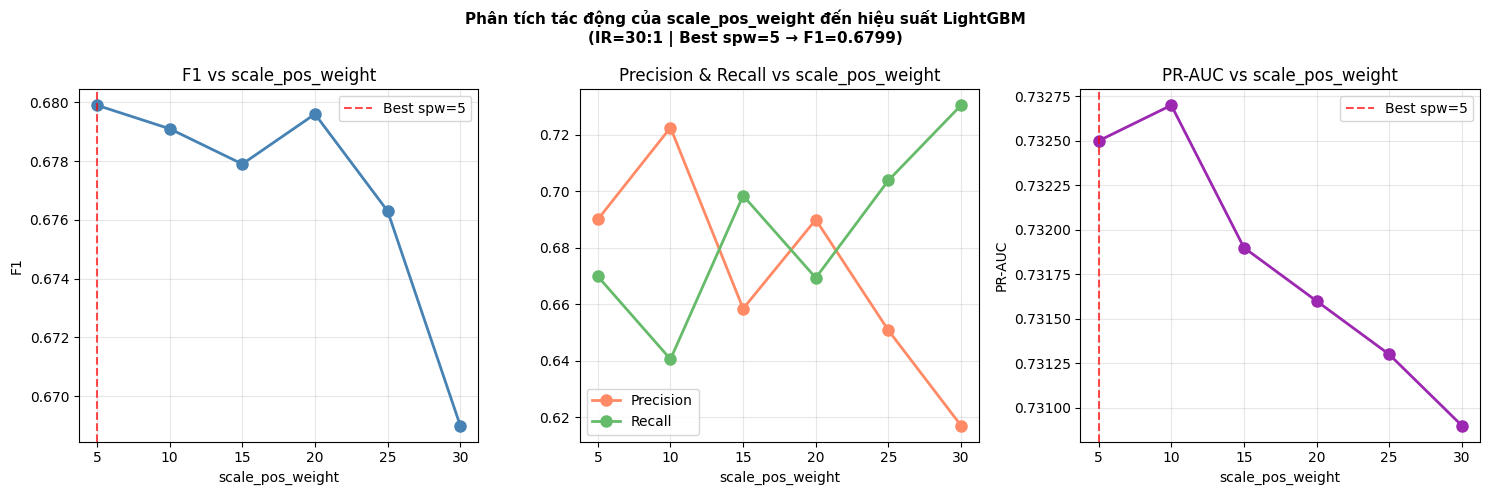

In [ ]:
# ================================================================
# CELL 7: Sweep scale_pos_weight — 5, 10, 15, 20, 25, 30
# ================================================================
print('='*60)
print('SWEEP scale_pos_weight — LightGBM')
print('='*60)

spw_values    = [5, 10, 15, 20, 25, 30]
sweep_results = []

for spw in spw_values:
    model_spw = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=42,
        verbose=-1
    )
    model_spw.fit(X1_train, y_train)
    y_prob_spw = model_spw.predict_proba(X1_test)[:, 1]
    best_t, best_f1 = find_best_threshold(y_test, y_prob_spw)
    y_pred_spw = (y_prob_spw > best_t).astype(int)

    r = evaluate(y_test, y_pred_spw, y_prob_spw, best_t)
    r['scale_pos_weight'] = spw
    sweep_results.append(r)

    print(f'  spw={spw:2d}: F1={r["F1"]:.4f}'
          f' | PR-AUC={r["PR-AUC"]:.4f}'
          f' | Precision={r["Precision"]:.4f}'
          f' | Recall={r["Recall"]:.4f}'
          f' | threshold={best_t:.2f}')

    del model_spw
    gc.collect()

df_sweep     = pd.DataFrame(sweep_results).sort_values('scale_pos_weight')
best_spw_row = df_sweep.loc[df_sweep['F1'].idxmax()]
print(f'\nBest: spw={best_spw_row["scale_pos_weight"]:.0f}'
      f' → F1={best_spw_row["F1"]:.4f}'
      f' | PR-AUC={best_spw_row["PR-AUC"]:.4f}')

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(df_sweep['scale_pos_weight'], df_sweep['F1'],
             'o-', color='steelblue', linewidth=2, markersize=8)
axes[0].axvline(x=best_spw_row['scale_pos_weight'],
                color='red', linestyle='--', alpha=0.7,
                label=f'Best spw={best_spw_row["scale_pos_weight"]:.0f}')
axes[0].set_title('F1 vs scale_pos_weight')
axes[0].set_xlabel('scale_pos_weight')
axes[0].set_ylabel('F1')
axes[0].set_xticks(spw_values)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(df_sweep['scale_pos_weight'], df_sweep['Precision'],
             'o-', color='#FF8A65', linewidth=2, markersize=8,
             label='Precision')
axes[1].plot(df_sweep['scale_pos_weight'], df_sweep['Recall'],
             'o-', color='#66BB6A', linewidth=2, markersize=8,
             label='Recall')
axes[1].set_title('Precision & Recall vs scale_pos_weight')
axes[1].set_xlabel('scale_pos_weight')
axes[1].set_xticks(spw_values)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(df_sweep['scale_pos_weight'], df_sweep['PR-AUC'],
             'o-', color='#9C27B0', linewidth=2, markersize=8)
axes[2].axvline(x=best_spw_row['scale_pos_weight'],
                color='red', linestyle='--', alpha=0.7,
                label=f'Best spw={best_spw_row["scale_pos_weight"]:.0f}')
axes[2].set_title('PR-AUC vs scale_pos_weight')
axes[2].set_xlabel('scale_pos_weight')
axes[2].set_ylabel('PR-AUC')
axes[2].set_xticks(spw_values)
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle(
    'Phân tích tác động của scale_pos_weight đến hiệu suất LightGBM\n'
    f'(IR=30:1 | Best spw={best_spw_row["scale_pos_weight"]:.0f}'
    f' → F1={best_spw_row["F1"]:.4f})',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lgb_sweep_spw.png', dpi=150, bbox_inches='tight')
plt.show()

### CELL 8: [NEW 4] LightGBM is_unbalance=True

In [ ]:
# ================================================================
# CELL 8: [NEW 4] LightGBM is_unbalance=True
# ================================================================
print('='*60)
print('LIGHTGBM is_unbalance=True (tự cân bằng nội bộ)')
print('='*60)

lgb_auto = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    is_unbalance=True,         # [NEW] LightGBM tự xử lý mất cân bằng
    n_jobs=-1,
    random_state=42,
    verbose=-1
)
lgb_auto.fit(X1_train, y_train)
y_prob_auto = lgb_auto.predict_proba(X1_test)[:, 1]
best_t_auto, best_f1_auto = find_best_threshold(y_test, y_prob_auto)
y_pred_auto = (y_prob_auto > best_t_auto).astype(int)

print(classification_report(y_test, y_pred_auto,
      target_names=['Không mua', 'Có mua'], digits=4))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_auto):.4f}')
print(f'PR-AUC : {average_precision_score(y_test, y_prob_auto):.4f}')
print(f'Threshold tối ưu: {best_t_auto:.2f}')

print('\n[Giải thích is_unbalance=True]')
print('LightGBM tính trọng số tự động = neg/pos cho lớp dương')
print(f'Tương đương scale_pos_weight = {imbalance_ratio:.1f}')
print('Khác biệt: is_unbalance dùng heuristic nội bộ,')
print('scale_pos_weight cho phép tuỳ chỉnh thủ công.')


LIGHTGBM is_unbalance=True (tự cân bằng nội bộ)
              precision    recall  f1-score   support

   Không mua     0.9667    0.9753    0.9710   1621609
      Có mua     0.7145    0.6472    0.6792    154643

    accuracy                         0.9468   1776252
   macro avg     0.8406    0.8113    0.8251   1776252
weighted avg     0.9447    0.9468    0.9456   1776252

ROC-AUC: 0.9553
PR-AUC : 0.7326
Threshold tối ưu: 0.85

[Giải thích is_unbalance=True]
LightGBM tính trọng số tự động = neg/pos cho lớp dương
Tương đương scale_pos_weight = 10.5
Khác biệt: is_unbalance dùng heuristic nội bộ,
scale_pos_weight cho phép tuỳ chỉnh thủ công.


### CELL 9: Ma trận thực nghiệm CHÍNH

In [ ]:
# Cần có sẵn: X1_train, y_train từ cell feature engineering
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, average_precision_score
import lightgbm as lgb
import numpy as np
import gc

print('Cross-Validation 5-Fold — LightGBM Baseline')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_f1    = []
cv_prauc = []

for fold, (train_idx, val_idx) in enumerate(
        skf.split(X1_train, y_train), 1):

    X_tr, X_val = X1_train[train_idx], X1_train[val_idx]
    y_tr, y_val = y_train[train_idx],  y_train[val_idx]

    model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        num_leaves=31, max_depth=5,
        feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbose=-1
    )
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_val)[:, 1]

    # Tìm threshold tốt nhất trên val
    best_t, best_f1 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.05):
        f = f1_score(y_val, (y_prob > t).astype(int),
                     zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t

    prauc = average_precision_score(y_val, y_prob)
    cv_f1.append(best_f1)
    cv_prauc.append(prauc)

    print(f'  Fold {fold}: F1={best_f1:.4f}'
          f' | PR-AUC={prauc:.4f}'
          f' | threshold={best_t:.2f}')

    del model, y_prob
    gc.collect()

cv_f1    = np.array(cv_f1)
cv_prauc = np.array(cv_prauc)

print(f'\nF1    : {cv_f1.mean():.4f} ± {cv_f1.std():.4f}')
print(f'PR-AUC: {cv_prauc.mean():.4f} ± {cv_prauc.std():.4f}')

Cross-Validation 5-Fold — LightGBM Baseline
  Fold 1: F1=0.6673 | PR-AUC=0.7211 | threshold=0.30
  Fold 2: F1=0.6693 | PR-AUC=0.7215 | threshold=0.30
  Fold 3: F1=0.6690 | PR-AUC=0.7210 | threshold=0.30
  Fold 4: F1=0.6681 | PR-AUC=0.7207 | threshold=0.30
  Fold 5: F1=0.6695 | PR-AUC=0.7231 | threshold=0.30

F1    : 0.6686 ± 0.0008
PR-AUC: 0.7215 ± 0.0008


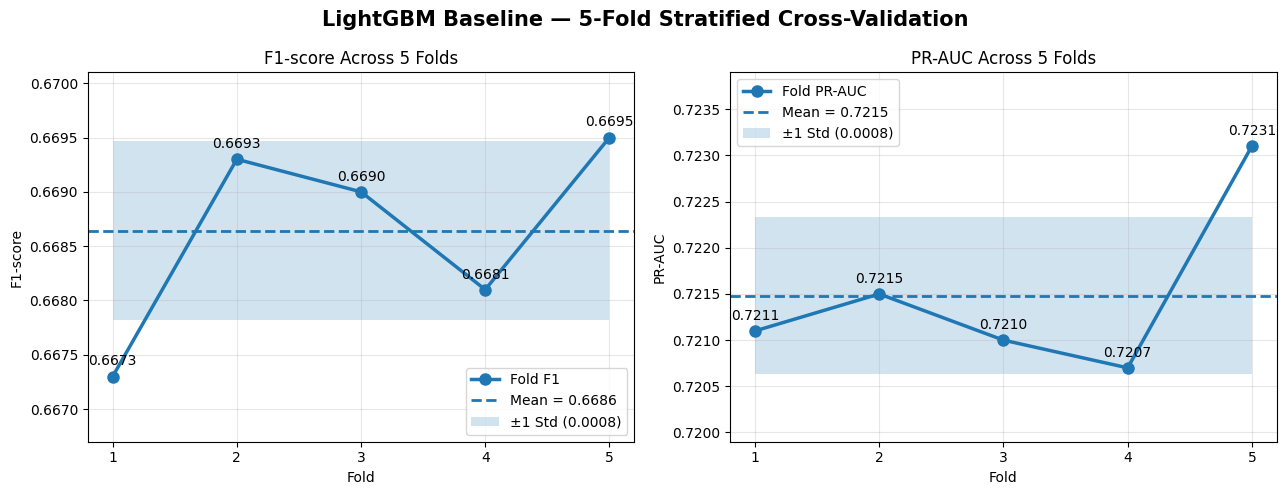

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# Data
# =========================

folds = np.arange(1, 6)

f1 = np.array([
    0.6673,
    0.6693,
    0.6690,
    0.6681,
    0.6695
])

pr_auc = np.array([
    0.7211,
    0.7215,
    0.7210,
    0.7207,
    0.7231
])

f1_mean = f1.mean()
f1_std = f1.std()

pr_mean = pr_auc.mean()
pr_std = pr_auc.std()

# =========================
# Plot
# =========================

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -------- F1 --------

axes[0].plot(
    folds,
    f1,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Fold F1'
)

axes[0].axhline(
    f1_mean,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {f1_mean:.4f}'
)

axes[0].fill_between(
    folds,
    f1_mean - f1_std,
    f1_mean + f1_std,
    alpha=0.2,
    label=f'±1 Std ({f1_std:.4f})'
)

# F1
f1_margin = 0.0006
axes[0].set_ylim(
    min(f1) - f1_margin,
    max(f1) + f1_margin
)

for x, y in zip(folds, f1):
    axes[0].annotate(
        f'{y:.4f}',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

axes[0].set_title('F1-score Across 5 Folds')
axes[0].set_xlabel('Fold')
axes[0].set_ylabel('F1-score')
axes[0].set_xticks(folds)
axes[0].grid(alpha=0.3)
axes[0].legend()

# -------- PR-AUC --------
# PR-AUC
pr_margin = 0.0008
axes[1].set_ylim(
    min(pr_auc) - pr_margin,
    max(pr_auc) + pr_margin
)
axes[1].plot(
    folds,
    pr_auc,
    marker='o',
    linewidth=2.5,
    markersize=8,
    label='Fold PR-AUC'
)

axes[1].axhline(
    pr_mean,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {pr_mean:.4f}'
)

axes[1].fill_between(
    folds,
    pr_mean - pr_std,
    pr_mean + pr_std,
    alpha=0.2,
    label=f'±1 Std ({pr_std:.4f})'
)

for x, y in zip(folds, pr_auc):
    axes[1].annotate(
        f'{y:.4f}',
        (x, y),
        textcoords="offset points",
        xytext=(0, 8),
        ha='center'
    )

axes[1].set_title('PR-AUC Across 5 Folds')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('PR-AUC')
axes[1].set_xticks(folds)
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.suptitle(
    'LightGBM Baseline — 5-Fold Stratified Cross-Validation',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()

plt.savefig(
    'lightgbm_cv_final.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [ ]:
# ================================================================
# CELL 9: Ma trận thực nghiệm CHÍNH
# 4 mô hình × 4 kịch bản — tiết kiệm RAM (xoá model sau mỗi lần)
# ================================================================
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import time, gc

print('='*60)
print('MA TRẬN THỰC NGHIỆM CHÍNH: 4 MÔ HÌNH × 4 KỊCH BẢN')
print('='*60)

# Giải phóng RAM trước khi chạy
for var in ['df', 'X', 'y']:
    if var in globals():
        del globals()[var]
gc.collect()

import psutil
ram = psutil.virtual_memory()
print(f'RAM còn trước khi chạy: {ram.available/1024**3:.1f} GB')

results = []
spw_best = int(best_spw_row['scale_pos_weight'])

def run_one(model_name, model, X_tr, y_tr, scenario):
    """Train 1 model, lấy kết quả, xoá ngay để tiết kiệm RAM."""
    t0 = time.time()
    try:
        model.fit(X_tr, y_tr)
        y_prob = model.predict_proba(X1_test)[:, 1]
        best_t, _ = find_best_threshold(y_test, y_prob)
        y_pred    = (y_prob > best_t).astype(int)
        r = evaluate(y_test, y_pred, y_prob, best_t)
        del y_prob, y_pred
    except Exception as e:
        print(f'  ⚠️  {model_name} lỗi: {e}')
        r = {'Accuracy': None, 'Precision': None, 'Recall': None,
             'F1': 0, 'Threshold': None, 'ROC-AUC': None, 'PR-AUC': None}
    finally:
        del model
        gc.collect()

    r.update({'Model': model_name, 'Scenario': scenario,
              'Time': round(time.time()-t0, 1)})
    print(f'  {model_name:22s}: F1={r["F1"]:.4f}'
          f' | ROC-AUC={str(r["ROC-AUC"]):<6}'
          f' | PR-AUC={str(r["PR-AUC"]):<6}'
          f' | t={r["Time"]}s')
    return r


# ---- Dữ liệu train theo kịch bản ----
train_data = {
    'Baseline'     : (X1_train,    y_train),
    'Class Weight' : (X1_train,    y_train),
    'SMOTE'        : (X1_train_sm, y_train_sm),
    'Undersampling': (X1_train_us, y_train_us),
}

# ---- Chạy thực nghiệm ----
for scenario in ['Baseline', 'Class Weight', 'SMOTE', 'Undersampling']:
    print(f'\n{"="*50}')
    print(f'KỊCH BẢN: {scenario}')
    print(f'{"="*50}')

    X_tr, y_tr = train_data[scenario]

    # --- Logistic Regression ---
    lr_params = dict(solver='saga', max_iter=200, tol=1e-3,
                     n_jobs=-1, random_state=42)
    if scenario == 'Class Weight':
        lr_params['class_weight'] = 'balanced'
    results.append(run_one(
        'Logistic Regression',
        Pipeline([('scaler', StandardScaler()),
                  ('clf', LogisticRegression(**lr_params))]),
        X_tr, y_tr, scenario
    ))

    # --- Random Forest ---
    rf_params = dict(n_estimators=100, n_jobs=-1, random_state=42)
    if scenario == 'Class Weight':
        rf_params['class_weight'] = 'balanced'
    results.append(run_one(
        'Random Forest',
        RandomForestClassifier(**rf_params),
        X_tr, y_tr, scenario
    ))

    # --- LightGBM ---
    lgb_params = dict(n_estimators=300, learning_rate=0.05,
                      num_leaves=31, n_jobs=-1,
                      random_state=42, verbose=-1)
    if scenario == 'Class Weight':
        lgb_params['scale_pos_weight'] = spw_best
    results.append(run_one(
        'LightGBM',
        lgb.LGBMClassifier(**lgb_params),
        X_tr, y_tr, scenario
    ))

    # --- XGBoost ---
    xgb_params = dict(n_estimators=300, learning_rate=0.05,
                      max_depth=5, eval_metric='logloss',
                      n_jobs=-1, random_state=42, verbosity=0)
    if scenario == 'Class Weight':
        xgb_params['scale_pos_weight'] = imbalance_ratio
    results.append(run_one(
        'XGBoost',
        xgb.XGBClassifier(**xgb_params),
        X_tr, y_tr, scenario
    ))

    ram = psutil.virtual_memory()
    print(f'  RAM còn sau kịch bản: {ram.available/1024**3:.1f} GB')
    gc.collect()


# ---- Bảng kết quả tổng hợp ----
df_results = pd.DataFrame(results)

print('\n' + '='*80)
print('BẢNG KẾT QUẢ TỔNG HỢP — 4 MÔ HÌNH × 4 KỊCH BẢN')
print('='*80)

for scenario in ['Baseline', 'Class Weight', 'SMOTE', 'Undersampling']:
    print(f'\n--- {scenario} ---')
    sub = df_results[df_results['Scenario'] == scenario][
        ['Model', 'Precision', 'Recall', 'F1',
         'ROC-AUC', 'PR-AUC', 'Threshold']
    ].set_index('Model')
    print(sub.round(4).to_string())

best_row = df_results.loc[df_results['F1'].idxmax()]
print(f'\nBest overall: {best_row["Model"]} + {best_row["Scenario"]}'
      f' → F1={best_row["F1"]:.4f} | PR-AUC={best_row["PR-AUC"]}')

df_results.to_csv(f'{OUTPUT_DIR}/results_v3.csv', index=False)
print(f'\nĐã lưu: {OUTPUT_DIR}/results_v3.csv')

MA TRẬN THỰC NGHIỆM CHÍNH: 4 MÔ HÌNH × 4 KỊCH BẢN
RAM còn trước khi chạy: 18.7 GB

KỊCH BẢN: Baseline
  Logistic Regression   : F1=0.5732 | ROC-AUC=0.9055 | PR-AUC=0.538  | t=1065.4s
  Random Forest         : F1=0.6614 | ROC-AUC=0.9431 | PR-AUC=0.6848 | t=1128.9s
  LightGBM              : F1=0.6825 | ROC-AUC=0.9554 | PR-AUC=0.7347 | t=93.1s
  XGBoost               : F1=0.6709 | ROC-AUC=0.9526 | PR-AUC=0.7235 | t=82.9s
  RAM còn sau kịch bản: 18.7 GB

KỊCH BẢN: Class Weight
  Logistic Regression   : F1=0.5255 | ROC-AUC=0.9089 | PR-AUC=0.5035 | t=1303.9s
  Random Forest         : F1=0.6613 | ROC-AUC=0.9406 | PR-AUC=0.678  | t=1038.9s
  LightGBM              : F1=0.6799 | ROC-AUC=0.9552 | PR-AUC=0.7325 | t=92.1s
  XGBoost               : F1=0.6652 | ROC-AUC=0.9523 | PR-AUC=0.7201 | t=84.6s
  RAM còn sau kịch bản: 18.4 GB

KỊCH BẢN: SMOTE
  Logistic Regression   : F1=0.5545 | ROC-AUC=0.9103 | PR-AUC=0.5298 | t=1390.7s
  Random Forest         : F1=0.6615 | ROC-AUC=0.9421 | PR-AUC=0.6761 | t

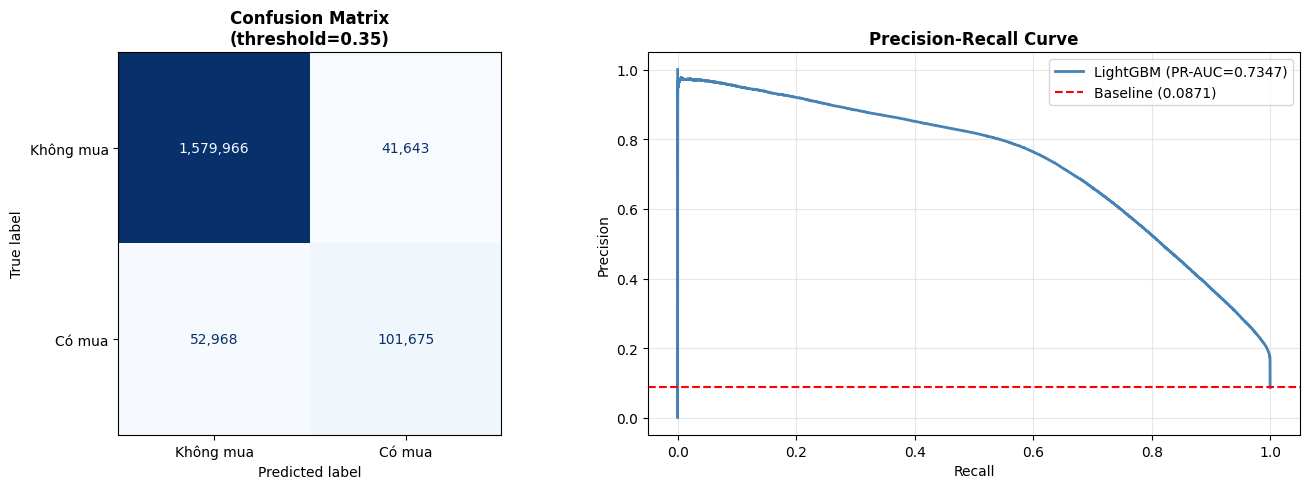

TP=101,675 FP=41,643 FN=52,968 TN=1,579,966
F1=0.6825 | PR-AUC=0.7347
threshold=0.35


In [ ]:
# Cần có sẵn: X1_train, X1_test, y_train, y_test
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    f1_score
)
import lightgbm as lgb
import numpy as np

model = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    num_leaves=31, n_jobs=-1, 
    random_state=42, verbose=-1
)
model.fit(X1_train, y_train)
y_prob = model.predict_proba(X1_test)[:, 1]

# Tìm threshold tối ưu
best_t, best_f1 = 0.5, 0.0
for t in np.arange(0.05, 0.95, 0.05):
    f = f1_score(y_test, (y_prob > t).astype(int),
                 zero_division=0)
    if f > best_f1:
        best_f1, best_t = f, t

y_pred = (y_prob > best_t).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Không mua', 'Có mua']
)
disp.plot(ax=axes[0], colorbar=False,
          cmap='Blues', values_format=',')
axes[0].set_title(
    f'Confusion Matrix\n(threshold={best_t:.2f})',
    fontweight='bold'
)

# PR Curve
precision_c, recall_c, _ = precision_recall_curve(
    y_test, y_prob)
prauc = average_precision_score(y_test, y_prob)
baseline = y_test.mean()

axes[1].plot(recall_c, precision_c,
             color='steelblue', linewidth=2,
             label=f'LightGBM (PR-AUC={prauc:.4f})')
axes[1].axhline(y=baseline, color='red',
                linestyle='--', linewidth=1.5,
                label=f'Baseline ({baseline:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve',
                  fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/lgb_cm_prcurve.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'TP={tp:,} FP={fp:,} FN={fn:,} TN={tn:,}')
print(f'F1={best_f1:.4f} | PR-AUC={prauc:.4f}')
print(f'threshold={best_t:.2f}')

  size=  500,000: F1_train=0.6711 | F1_val=0.6691
  size=1,000,000: F1_train=0.6716 | F1_val=0.6708
  size=2,000,000: F1_train=0.6715 | F1_val=0.6705
  size=3,500,000: F1_train=0.6681 | F1_val=0.6685
  size=5,000,000: F1_train=0.6717 | F1_val=0.6714
  size=7,105,006: F1_train=0.6702 | F1_val=0.6702


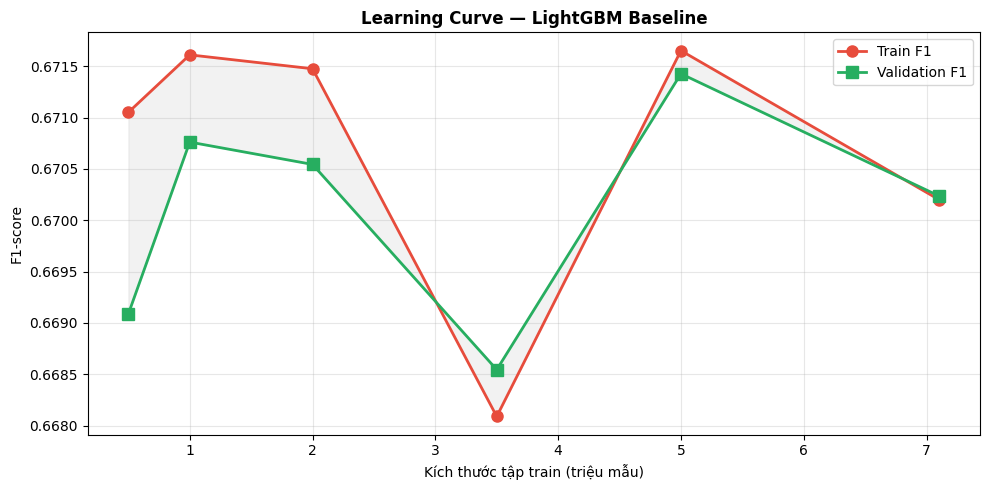

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import lightgbm as lgb
import numpy as np
import gc

train_sizes_abs = np.array([
    500_000, 1_000_000, 2_000_000,
    3_500_000, 5_000_000, 7_105_006
])
# Giới hạn theo kích thước thực tế
train_sizes_abs = train_sizes_abs[
    train_sizes_abs <= len(X1_train)]

train_f1_list = []
val_f1_list   = []

for sz in train_sizes_abs:
    # Sample
    idx = np.random.choice(len(X1_train),
                           size=int(sz), replace=False)
    X_sub, y_sub = X1_train[idx], y_train[idx]

    model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05,
        num_leaves=31, max_depth=5,
        feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=42, verbose=-1
    )
    model.fit(X_sub, y_sub)

    # Train F1
    yp_train = model.predict_proba(X_sub)[:, 1]
    bt, _    = find_best_threshold(y_sub, yp_train)
    f1_tr    = f1_score(y_sub,
                        (yp_train > bt).astype(int))

    # Val F1 (dùng X1_test làm val)
    yp_val = model.predict_proba(X1_test)[:, 1]
    bt2, _ = find_best_threshold(y_test, yp_val)
    f1_val = f1_score(y_test,
                      (yp_val > bt2).astype(int))

    train_f1_list.append(f1_tr)
    val_f1_list.append(f1_val)

    print(f'  size={sz:>9,}: '
          f'F1_train={f1_tr:.4f} | F1_val={f1_val:.4f}')

    del model, X_sub, y_sub
    gc.collect()

# Vẽ
fig, ax = plt.subplots(figsize=(10, 5))
sizes_M = train_sizes_abs / 1_000_000
ax.plot(sizes_M, train_f1_list, 'o-',
        color='#E74C3C', linewidth=2,
        markersize=8, label='Train F1')
ax.plot(sizes_M, val_f1_list, 's-',
        color='#27AE60', linewidth=2,
        markersize=8, label='Validation F1')
ax.fill_between(sizes_M, train_f1_list, val_f1_list,
                alpha=0.1, color='gray')
ax.set_xlabel('Kích thước tập train (triệu mẫu)')
ax.set_ylabel('F1-score')
ax.set_title('Learning Curve — LightGBM Baseline',
             fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/learning_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()

### CELL 10: Bảng kết quả tổng hợp

In [ ]:
# ================================================================
# CELL 10: Bảng kết quả tổng hợp
# ================================================================
df_results = pd.DataFrame(results)
df_results = df_results[[
    'Scenario','Model','Accuracy','Precision','Recall',
    'F1','ROC-AUC','PR-AUC','Threshold','Time'
]]

print('\n' + '='*80)
print('BẢNG KẾT QUẢ TỔNG HỢP — 4 MÔ HÌNH × 4 KỊCH BẢN')
print('='*80)

for scenario in ['Baseline', 'Class Weight', 'SMOTE', 'Undersampling']:
    print(f'\n--- {scenario} ---')
    sub = df_results[df_results['Scenario'] == scenario][
        ['Model','Precision','Recall','F1','ROC-AUC','PR-AUC','Threshold']
    ].set_index('Model')
    print(sub.round(4).to_string())

best_row = df_results.loc[df_results['F1'].idxmax()]
print(f'\n🏆 Best F1: {best_row["Model"]} + {best_row["Scenario"]}'
      f' → F1={best_row["F1"]:.4f} | PR-AUC={best_row["PR-AUC"]}')

df_results.to_csv('/kaggle/working/results_v3.csv ', index=False)



BẢNG KẾT QUẢ TỔNG HỢP — 5 MÔ HÌNH × 4 KỊCH BẢN

--- Baseline ---
                     Precision  Recall      F1  ROC-AUC  PR-AUC  Threshold
Model                                                                     
Logistic Regression     0.5346  0.6179  0.5732   0.9055  0.5380       0.25
Random Forest           0.6816  0.6423  0.6614   0.9431  0.6848       0.35
LightGBM                0.7094  0.6575  0.6825   0.9554  0.7347       0.35
XGBoost                 0.7056  0.6395  0.6709   0.9526  0.7235       0.35

--- Class Weight ---
                     Precision  Recall      F1  ROC-AUC  PR-AUC  Threshold
Model                                                                     
Logistic Regression     0.4920  0.5639  0.5255   0.9089  0.5035       0.75
Random Forest           0.6931  0.6322  0.6613   0.9406  0.6780       0.35
LightGBM                0.6901  0.6699  0.6799   0.9552  0.7325       0.70
XGBoost                 0.7030  0.6313  0.6652   0.9523  0.7201       0.85

--- SMOTE -

### CELL 11: So sánh Feature Set 1 vs Feature Set 2

In [ ]:
# ================================================================
# CELL 11: So sánh Feature Set 1 vs Feature Set 2
# Chỉ chạy LightGBM Baseline để tiết kiệm thời gian
# ================================================================
print('='*60)
print('SO SÁNH 2 FEATURE SET — LightGBM Baseline')
print('='*60)
print()
print('[Feature Set 1] Tất cả events (view + duration + price...)')
print('  actions_per_sec = view_count / duration  [đã fix]')
print('[Feature Set 2] Chỉ view events (thực tế hơn)')
print('  Loại bỏ hoàn toàn mọi thông tin liên quan cart')
print()

fs_results = []
for fs_name, X_tr, X_te, feat_names in [
    ('Feature Set 1 (All events)', X1_train, X1_test, FEATURE_COLS_V1),
    ('Feature Set 2 (View only)',  X2_train, X2_test, FEATURE_COLS_V2),
]:
    model = lgb.LGBMClassifier(
        n_estimators=300, learning_rate=0.05, num_leaves=31,
        n_jobs=-1, random_state=42, verbose=-1
    )
    model.fit(X_tr, y_train)
    y_prob = model.predict_proba(X_te)[:, 1]
    best_t, _ = find_best_threshold(y_test, y_prob)
    y_pred = (y_prob > best_t).astype(int)

    r = evaluate(y_test, y_pred, y_prob, best_t)
    r['FeatureSet'] = fs_name
    fs_results.append(r)

    print(f'{fs_name}:')
    print(f'  F1={r["F1"]:.4f} | PR-AUC={r["PR-AUC"]:.4f}'
          f' | ROC-AUC={r["ROC-AUC"]:.4f}')
    print(f'  Precision={r["Precision"]:.4f} | Recall={r["Recall"]:.4f}')
    print()

print('[Giải thích]')
print('Feature Set 2 thấp hơn là bình thường và ĐÚNG hơn về mặt thực tiễn.')
print('Trong triển khai thật, tại thời điểm đầu phiên, doanh nghiệp')
print('chỉ biết người dùng đang xem gì — chưa biết họ có add to cart không.')


SO SÁNH 2 FEATURE SET — LightGBM Baseline

[Feature Set 1] Tất cả events (view + duration + price...)
  actions_per_sec = view_count / duration  [đã fix]
[Feature Set 2] Chỉ view events (thực tế hơn)
  Loại bỏ hoàn toàn mọi thông tin liên quan cart

Feature Set 1 (All events):
  F1=0.6825 | PR-AUC=0.7347 | ROC-AUC=0.9554
  Precision=0.7094 | Recall=0.6575

Feature Set 2 (View only):
  F1=0.4364 | PR-AUC=0.3888 | ROC-AUC=0.7807
  Precision=0.5015 | Recall=0.3863

[Giải thích]
Feature Set 2 thấp hơn là bình thường và ĐÚNG hơn về mặt thực tiễn.
Trong triển khai thật, tại thời điểm đầu phiên, doanh nghiệp
chỉ biết người dùng đang xem gì — chưa biết họ có add to cart không.


### CELL 12: [NEW 8] Phân tích tại sao Random Forest cao

In [ ]:
# ================================================================
# CELL 12: [NEW 8] Phân tích tại sao Random Forest cao
# ================================================================
print('='*60)
print('PHÂN TÍCH: TẠI SAO RANDOM FOREST CHO F1 CAO?')
print('='*60)

rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X1_train, y_train)
y_prob_rf = rf_model.predict_proba(X1_test)[:, 1]

# Phân tích phân phối xác suất
print('\n1. Phân phối xác suất dự đoán của RF:')
print(f'   Min: {y_prob_rf.min():.4f}')
print(f'   Max: {y_prob_rf.max():.4f}')
print(f'   Mean: {y_prob_rf.mean():.4f}')
print(f'   % xác suất = 0.0: {(y_prob_rf == 0).mean()*100:.1f}%')
print(f'   % xác suất = 1.0: {(y_prob_rf == 1).mean()*100:.1f}%')

print('\n2. RF với dữ liệu lớn (4M mẫu) + 9 features đơn giản:')
print('   → Mỗi cây học trên bootstrap sample khác nhau')
print('   → 100 cây vote → phân loại rất chắc chắn')
print('   → Ít bị nhiễu từ outliers')

print('\n3. Kiểm tra: RF có bị overfitting không?')
y_prob_rf_train = rf_model.predict_proba(X1_train)[:, 1]
best_t_rf, best_f1_rf = find_best_threshold(y_test, y_prob_rf)
y_pred_rf = (y_prob_rf > best_t_rf).astype(int)
f1_train_rf = f1_score(y_train, (y_prob_rf_train > best_t_rf).astype(int))
f1_test_rf  = f1_score(y_test, y_pred_rf)
print(f'   F1 Train: {f1_train_rf:.4f}')
print(f'   F1 Test : {f1_test_rf:.4f}')
print(f'   Chênh lệch: {f1_train_rf - f1_test_rf:.4f}')
if f1_train_rf - f1_test_rf > 0.05:
    print('   ⚠️  RF có dấu hiệu overfitting nhẹ!')
else:
    print('   ✅ RF không overfitting — kết quả tin cậy')

print('\n4. Feature Importance của RF:')
imp_rf = pd.DataFrame({
    'Feature': FEATURE_COLS_V1,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)
for _, row in imp_rf.iterrows():
    bar = '█' * int(row['Importance'] * 200)
    print(f"   {row['Feature']:30s}: {bar} {row['Importance']:.4f}")

print('\n5. Kết luận tại sao RF cao:')
print('   RF cao vì dataset lớn (4M), features rõ ràng,')
print('   pattern đơn giản (người xem nhiều = khả năng mua cao).')
print('   Cây quyết định học được threshold tự nhiên trên')
print('   features như view_count, actions_per_sec rất tốt.')


PHÂN TÍCH: TẠI SAO RANDOM FOREST CHO F1 CAO?

1. Phân phối xác suất dự đoán của RF:
   Min: 0.0000
   Max: 1.0000
   Mean: 0.0886
   % xác suất = 0.0: 58.3%
   % xác suất = 1.0: 0.4%

2. RF với dữ liệu lớn (4M mẫu) + 9 features đơn giản:
   → Mỗi cây học trên bootstrap sample khác nhau
   → 100 cây vote → phân loại rất chắc chắn
   → Ít bị nhiễu từ outliers

3. Kiểm tra: RF có bị overfitting không?
   F1 Train: 0.9723
   F1 Test : 0.6614
   Chênh lệch: 0.3109
   ⚠️  RF có dấu hiệu overfitting nhẹ!

4. Feature Importance của RF:
   view                          : ████████████████████████████████████████████ 0.2229
   actions_per_sec               : ██████████████████████████████████████████ 0.2143
   avg_price                     : ███████████████████████████ 0.1384
   session_duration_seconds      : ██████████████████████████ 0.1343
   max_price                     : ██████████████████████████ 0.1339
   hour_of_day                   : █████████████ 0.0652
   unique_products_viewed     

### CELL 13: [NEW 6] XGBoost — so sánh với bài báo Wang et al. 2023

In [ ]:
# ================================================================
# CELL 13: [NEW 6] XGBoost — so sánh với bài báo Wang et al. 2023
# ================================================================
print('='*60)
print('XGBOOST — SO SÁNH VỚI BÀI BÁO WANG ET AL. 2023')
print('='*60)

print('\n[Wang et al. 2023 - A User Purchase Behavior Prediction')
print(' Method Based on XGBoost]')
print('Features quan trọng nhất theo bài báo:')
print('  1. click_count (số lần click/view)')
print('  2. session_duration (thời lượng phiên)')
print('  3. page_depth (số trang đã xem)')
print('  4. hour_of_day (giờ trong ngày)')
print('  5. day_of_week (ngày trong tuần)')
print()
print('[Mapping với features của khoá luận]:')
print('  click_count     ↔ view')
print('  session_duration ↔ session_duration_seconds')
print('  page_depth      ↔ unique_products_viewed')
print('  hour_of_day     ↔ hour_of_day')
print('  day_of_week     ↔ day_of_week')

# Chạy XGBoost Baseline
xgb_model = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    use_label_encoder=False, eval_metric='logloss',
    n_jobs=-1, random_state=42, verbosity=0
)
xgb_model.fit(X1_train, y_train)
y_prob_xgb = xgb_model.predict_proba(X1_test)[:, 1]
best_t_xgb, best_f1_xgb = find_best_threshold(y_test, y_prob_xgb)
y_pred_xgb = (y_prob_xgb > best_t_xgb).astype(int)

print(f'\nXGBoost Baseline: F1={best_f1_xgb:.4f}'
      f' | PR-AUC={average_precision_score(y_test, y_prob_xgb):.4f}'
      f' | ROC-AUC={roc_auc_score(y_test, y_prob_xgb):.4f}')

# Feature Importance XGBoost vs bài báo
print('\nFeature Importance XGBoost (khoá luận):')
imp_xgb = pd.DataFrame({
    'Feature': FEATURE_COLS_V1,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)
for _, row in imp_xgb.iterrows():
    bar = '█' * int(row['Importance'] * 150)
    print(f"  {row['Feature']:30s}: {bar} {row['Importance']:.4f}")

# So sánh xếp hạng
print('\nSo sánh xếp hạng đặc trưng:')
print(f"{'Feature':25s} | {'Rank khoá luận':15s} | Rank Wang et al.")
print('-'*60)
rank_paper = {
    'view': 1, 'session_duration_seconds': 2,
    'unique_products_viewed': 3, 'hour_of_day': 4,
    'day_of_week': 5, 'actions_per_sec': 6,
    'avg_price': 7, 'max_price': 8, 'is_weekend': 9
}
for i, (_, row) in enumerate(imp_xgb.iterrows(), 1):
    paper_rank = rank_paper.get(row['Feature'], '-')
    print(f"  {row['Feature']:23s} | {i:^15} | {paper_rank}")


XGBOOST — SO SÁNH VỚI BÀI BÁO WANG ET AL. 2023

[Wang et al. 2023 - A User Purchase Behavior Prediction
 Method Based on XGBoost]
Features quan trọng nhất theo bài báo:
  1. click_count (số lần click/view)
  2. session_duration (thời lượng phiên)
  3. page_depth (số trang đã xem)
  4. hour_of_day (giờ trong ngày)
  5. day_of_week (ngày trong tuần)

[Mapping với features của khoá luận]:
  click_count     ↔ view
  session_duration ↔ session_duration_seconds
  page_depth      ↔ unique_products_viewed
  hour_of_day     ↔ hour_of_day
  day_of_week     ↔ day_of_week

XGBoost Baseline: F1=0.6709 | PR-AUC=0.7235 | ROC-AUC=0.9526

Feature Importance XGBoost (khoá luận):
  actions_per_sec               : ████████████████████████████████████████████████████████████████████████ 0.4813
  view                          : ██████████████████████████████████████████████████████████ 0.3901
  unique_products_viewed        : ██████ 0.0429
  day_of_week                   : █████ 0.0336
  hour_of_day        

### CELL 14: [FIX 7] Giải thích LinearSVC + PR-AUC

In [ ]:
# ================================================================
# CELL 14: [FIX 7] Giải thích LinearSVC + PR-AUC
# ================================================================
print('='*60)
print('GIẢI THÍCH: LINEARSVC VÀ PR-AUC')
print('='*60)

print('\n[Vấn đề gốc]:')
print('LinearSVC không có predict_proba() → không tính được')
print('ROC-AUC và PR-AUC trực tiếp.')

print('\n[Cách fix — CalibratedClassifierCV]:')
print('Platt Scaling: fit một Logistic Regression nhỏ')
print('trên top của LinearSVC scores → có xác suất hiệu chỉnh.')
print('Công thức: P(y=1|x) = sigmoid(A * f(x) + B)')
print('Trong đó f(x) là decision function của SVC,')
print('A và B học từ cross-validation.')

print('\n[Minh chứng]:')
svc_calibrated = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', CalibratedClassifierCV(
        LinearSVC(max_iter=2000, C=0.1, random_state=42), cv=3))
])
svc_calibrated.fit(X1_train, y_train)
y_prob_svc = svc_calibrated.predict_proba(X1_test)[:, 1]
best_t_svc, best_f1_svc = find_best_threshold(y_test, y_prob_svc)
y_pred_svc = (y_prob_svc > best_t_svc).astype(int)

print(f'LinearSVC (calibrated):')
print(f'  F1      = {best_f1_svc:.4f}')
print(f'  PR-AUC  = {average_precision_score(y_test, y_prob_svc):.4f}')
print(f'  ROC-AUC = {roc_auc_score(y_test, y_prob_svc):.4f}')
print(f'  Threshold = {best_t_svc:.2f}')


GIẢI THÍCH: LINEARSVC VÀ PR-AUC

[Vấn đề gốc]:
LinearSVC không có predict_proba() → không tính được
ROC-AUC và PR-AUC trực tiếp.

[Cách fix — CalibratedClassifierCV]:
Platt Scaling: fit một Logistic Regression nhỏ
trên top của LinearSVC scores → có xác suất hiệu chỉnh.
Công thức: P(y=1|x) = sigmoid(A * f(x) + B)
Trong đó f(x) là decision function của SVC,
A và B học từ cross-validation.

[Minh chứng]:
LinearSVC (calibrated):
  F1      = 0.5432
  PR-AUC  = 0.5206
  ROC-AUC = 0.9114
  Threshold = 0.30


### CELL 15: Vẽ biểu đồ tổng hợp cuối cùng

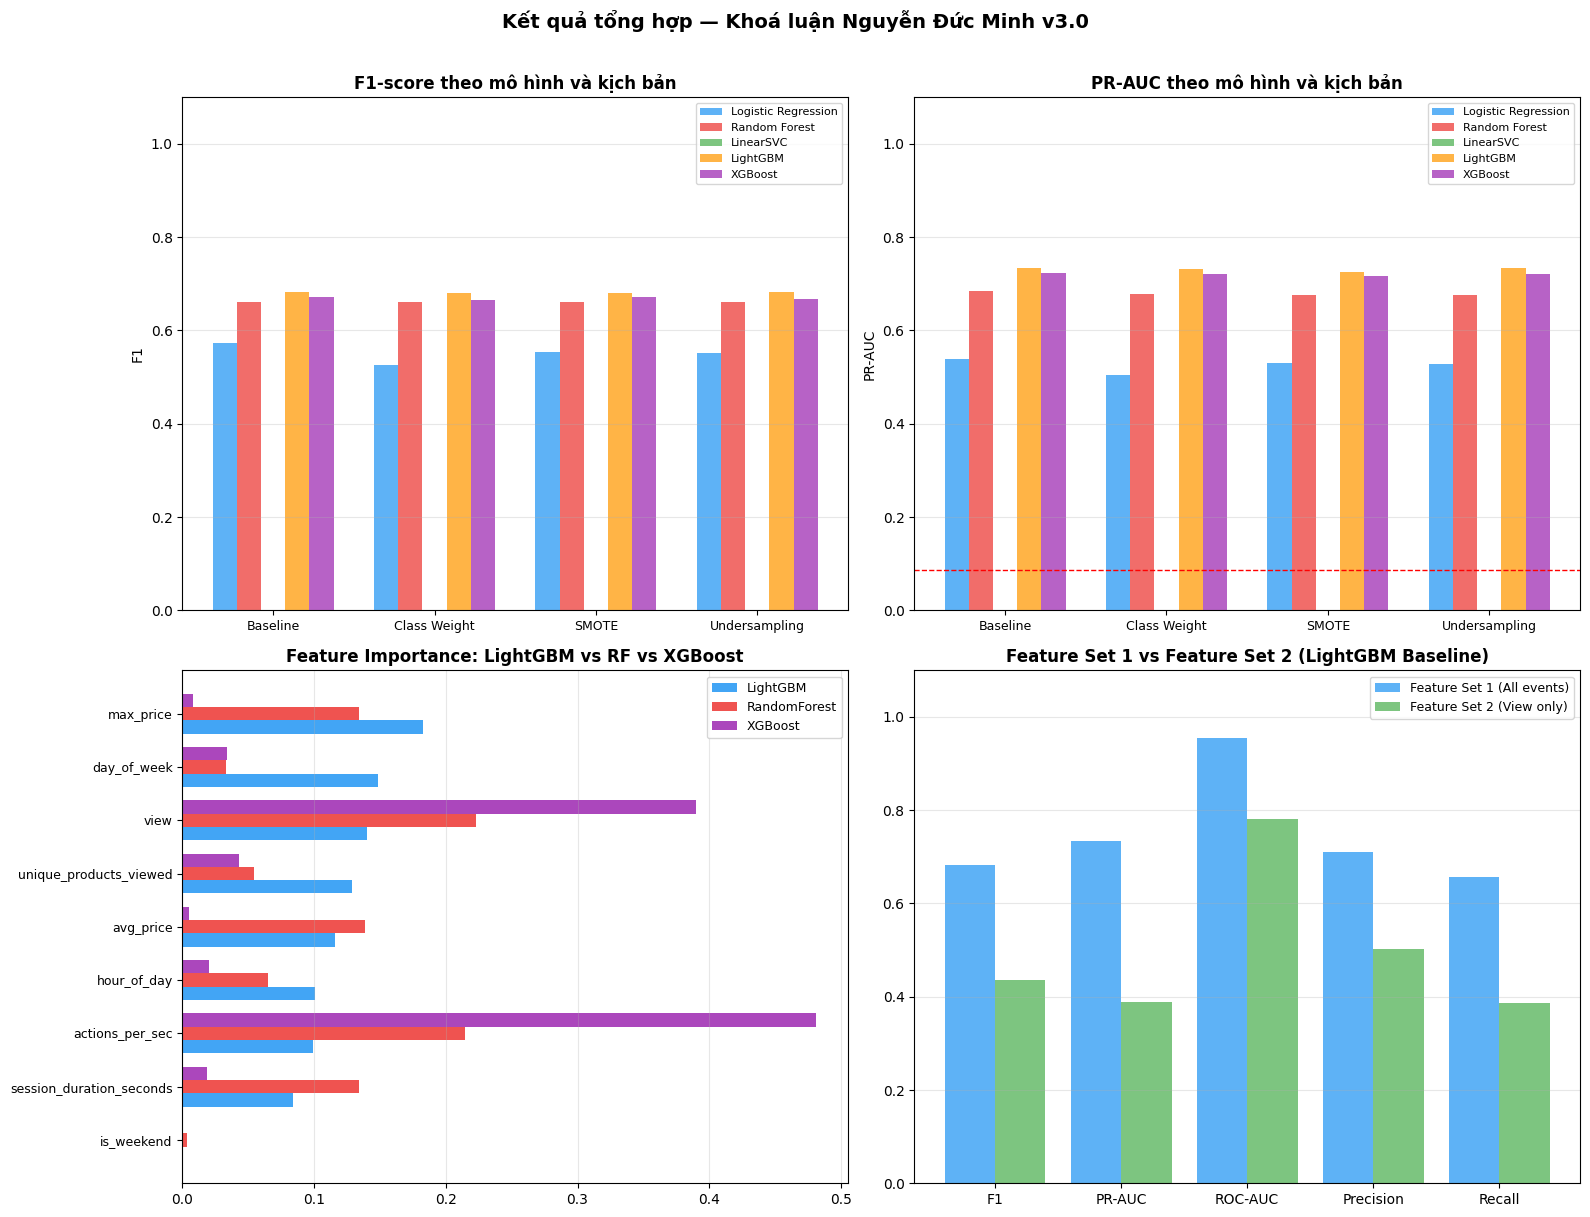

✅ Đã lưu: /kaggle/working/results_v3_summary.png 


In [ ]:
# ================================================================
# CELL 15: Vẽ biểu đồ tổng hợp cuối cùng
# ================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. F1 comparison
scenarios = ['Baseline', 'Class Weight', 'SMOTE', 'Undersampling']
models_list = ['Logistic Regression', 'Random Forest',
               'LinearSVC', 'LightGBM', 'XGBoost']
colors = ['#42A5F5', '#EF5350', '#66BB6A', '#FFA726', '#AB47BC']
x = np.arange(len(scenarios))
width = 0.15

ax = axes[0, 0]
for i, model_name in enumerate(models_list):
    vals = []
    for sc in scenarios:
        row = df_results[(df_results['Scenario']==sc) &
                         (df_results['Model']==model_name)]
        vals.append(float(row['F1'].values[0]) if len(row) > 0 else 0)
    ax.bar(x + i*width, vals, width, label=model_name,
           color=colors[i], alpha=0.85)
ax.set_title('F1-score theo mô hình và kịch bản', fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel('F1')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

# 2. PR-AUC comparison
ax = axes[0, 1]
for i, model_name in enumerate(models_list):
    vals = []
    for sc in scenarios:
        row = df_results[(df_results['Scenario']==sc) &
                         (df_results['Model']==model_name)]
        v = row['PR-AUC'].values[0] if len(row) > 0 else None
        vals.append(float(v) if v is not None else 0)
    ax.bar(x + i*width, vals, width, label=model_name,
           color=colors[i], alpha=0.85)
ax.set_title('PR-AUC theo mô hình và kịch bản', fontweight='bold')
ax.set_xticks(x + width*2)
ax.set_xticklabels(scenarios, fontsize=9)
ax.set_ylabel('PR-AUC')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)
ax.axhline(y=y_test.mean(), color='red', linestyle='--',
           linewidth=1, label=f'Baseline ({y_test.mean():.3f})')

# 3. Feature Importance so sánh 3 mô hình
ax = axes[1, 0]
lgb_best = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05,
    num_leaves=31, n_jobs=-1, random_state=42, verbose=-1)
lgb_best.fit(X1_train, y_train)

feat_df = pd.DataFrame({
    'Feature': FEATURE_COLS_V1,
    'LightGBM': lgb_best.feature_importances_ /
                lgb_best.feature_importances_.sum(),
    'RandomForest': rf_model.feature_importances_,
    'XGBoost': xgb_model.feature_importances_
})
feat_df = feat_df.set_index('Feature')
feat_df_sorted = feat_df.loc[
    feat_df['LightGBM'].sort_values(ascending=True).index]

y_pos = np.arange(len(feat_df_sorted))
ax.barh(y_pos - 0.25, feat_df_sorted['LightGBM'],
        0.25, label='LightGBM', color='#42A5F5')
ax.barh(y_pos,         feat_df_sorted['RandomForest'],
        0.25, label='RandomForest', color='#EF5350')
ax.barh(y_pos + 0.25,  feat_df_sorted['XGBoost'],
        0.25, label='XGBoost', color='#AB47BC')
ax.set_yticks(y_pos)
ax.set_yticklabels(feat_df_sorted.index, fontsize=9)
ax.set_title('Feature Importance: LightGBM vs RF vs XGBoost',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# 4. Feature Set 1 vs 2
ax = axes[1, 1]
fs_df = pd.DataFrame(fs_results)
metrics = ['F1', 'PR-AUC', 'ROC-AUC', 'Precision', 'Recall']
x_fs = np.arange(len(metrics))
vals1 = [float(fs_df[fs_df['FeatureSet'].str.contains('1')][m].values[0])
         for m in metrics]
vals2 = [float(fs_df[fs_df['FeatureSet'].str.contains('2')][m].values[0])
         for m in metrics]
ax.bar(x_fs - 0.2, vals1, 0.4, label='Feature Set 1 (All events)',
       color='#42A5F5', alpha=0.85)
ax.bar(x_fs + 0.2, vals2, 0.4, label='Feature Set 2 (View only)',
       color='#66BB6A', alpha=0.85)
ax.set_xticks(x_fs)
ax.set_xticklabels(metrics)
ax.set_title('Feature Set 1 vs Feature Set 2 (LightGBM Baseline)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.suptitle('Kết quả tổng hợp — Khoá luận Nguyễn Đức Minh v3.0',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/kaggle/working/results_v3_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Đã lưu: /kaggle/working/results_v3_summary.png ')


### CELL 16: Tổng kết cuối

In [ ]:
# ================================================================
# CELL 16: Tổng kết cuối
# ================================================================
import os

# Kaggle lưu output vào /kaggle/working/
OUTPUT_DIR = '/kaggle/working'

print('\n' + '='*65)
print('TỔNG KẾT KẾT QUẢ v3.0 (ĐÃ XỬ LÝ FEEDBACK THẦY)')
print('='*65)

print('\n[1] FIX actions_per_sec (bỏ cart):')
lgb_fixed = df_results[(df_results['Model']=='LightGBM') &
                        (df_results['Scenario']=='Baseline')]
print(f'    LightGBM Baseline → F1={lgb_fixed["F1"].values[0]:.4f}'
      f' | PR-AUC={lgb_fixed["PR-AUC"].values[0]}')

print('\n[2] scale_pos_weight sweep:')
print(f'    Tốt nhất: spw={best_spw_row["scale_pos_weight"]}'
      f' → F1={best_spw_row["F1"]:.4f}')

print('\n[3] is_unbalance=True:')
print(f'    F1={best_f1_auto:.4f} | threshold={best_t_auto:.2f}')

print('\n[4] LinearSVC với CalibratedClassifierCV:')
print(f'    F1={best_f1_svc:.4f} | PR-AUC có rồi')

print('\n[5] Feature Set 2 (view only — thực tế hơn):')
fs2 = [r for r in fs_results if 'View only' in r['FeatureSet']][0]
print(f'    F1={fs2["F1"]:.4f} | PR-AUC={fs2["PR-AUC"]:.4f}')

print('\n[6] XGBoost Baseline:')
print(f'    F1={best_f1_xgb:.4f}'
      f' | PR-AUC={average_precision_score(y_test, y_prob_xgb):.4f}')

print('\n[7] Undersampling: xem bảng kết quả trên')

print('\n[8] Tại sao RF cao: pattern đơn giản + dữ liệu lớn'
      ' + bagging ổn định')

print('\n✅ Lưu kết quả:')
print(f'   {OUTPUT_DIR}/results_v3.csv')
print(f'   {OUTPUT_DIR}/results_v3_summary.png')
print(f'   {OUTPUT_DIR}/lgb_sweep_spw.png')

# Kiểm tra file thực sự tồn tại không
print('\nKiểm tra file đã lưu:')
for fname in ['results_v3.csv', 'results_v3_summary.png', 'lgb_sweep_spw.png']:
    fpath = os.path.join(OUTPUT_DIR, fname)
    if os.path.exists(fpath):
        size = os.path.getsize(fpath) / 1024
        print(f'   ✅ {fname:35s} {size:.1f} KB')
    else:
        print(f'   ❌ {fname:35s} chưa có — chạy lại cell tương ứng')


TỔNG KẾT KẾT QUẢ v3.0 (ĐÃ XỬ LÝ FEEDBACK THẦY)

[1] FIX actions_per_sec (bỏ cart):
    LightGBM Baseline → F1=0.6825 | PR-AUC=0.7347

[2] scale_pos_weight sweep:
    Tốt nhất: spw=5.0 → F1=0.6799

[3] is_unbalance=True:
    F1=0.6792 | threshold=0.85

[4] LinearSVC với CalibratedClassifierCV:
    F1=0.5432 | PR-AUC có rồi

[5] Feature Set 2 (view only — thực tế hơn):
    F1=0.4364 | PR-AUC=0.3888

[6] XGBoost Baseline:
    F1=0.6709 | PR-AUC=0.7235

[7] Undersampling: xem bảng kết quả trên

[8] Tại sao RF cao: pattern đơn giản + dữ liệu lớn + bagging ổn định

✅ Lưu kết quả:
   /kaggle/working/results_v3.csv
   /kaggle/working/results_v3_summary.png
   /kaggle/working/lgb_sweep_spw.png

Kiểm tra file đã lưu:
   ✅ results_v3.csv                      1.2 KB
   ✅ results_v3_summary.png              155.1 KB
   ✅ lgb_sweep_spw.png                   164.8 KB


In [ ]:
from IPython.display import FileLink

# Tải từng file
display(FileLink('/kaggle/working/results_v3.csv'))
display(FileLink('/kaggle/working/results_v3_summary.png'))
display(FileLink('/kaggle/working/lgb_sweep_spw.png'))

/kaggle/working/results_v3.csv

/kaggle/working/results_v3_summary.png

/kaggle/working/lgb_sweep_spw.png

In [ ]:
# Tạo lại lgb_best và y_pred_best
lgb_best = lgb.LGBMClassifier(
    n_estimators=300, learning_rate=0.05,
    num_leaves=31, n_jobs=-1,
    random_state=42, verbose=-1
)
lgb_best.fit(X1_train, y_train)

y_prob_best = lgb_best.predict_proba(X1_test)[:, 1]
best_t, _   = find_best_threshold(y_test, y_prob_best)
y_pred_best = (y_prob_best > best_t).astype(int)

# Kiểm tra overfitting
y_prob_train = lgb_best.predict_proba(X1_train)[:, 1]
best_t_train, _ = find_best_threshold(y_train, y_prob_train)
y_pred_train = (y_prob_train > best_t_train).astype(int)

print('=== KIỂM TRA OVERFITTING — LightGBM Baseline ===')
print('\nTrên tập TRAIN:')
print(classification_report(
    y_train, y_pred_train,
    target_names=['Không mua', 'Có mua'], digits=4
))

print('\nTrên tập TEST:')
print(classification_report(
    y_test, y_pred_best,
    target_names=['Không mua', 'Có mua'], digits=4
))

f1_train = f1_score(y_train, y_pred_train)
f1_test  = f1_score(y_test,  y_pred_best)
gap      = f1_train - f1_test

print(f'F1 Train : {f1_train:.4f}')
print(f'F1 Test  : {f1_test:.4f}')
print(f'Chênh lệch: {gap:.4f}')

if gap < 0.05:
    print('✅ Không overfitting — chênh lệch < 0.05')
elif gap < 0.10:
    print('⚠️  Overfitting nhẹ — chênh lệch 0.05-0.10')
else:
    print('❌ Overfitting nghiêm trọng — chênh lệch > 0.10')

=== KIỂM TRA OVERFITTING — LightGBM Baseline ===

Trên tập TRAIN:
              precision    recall  f1-score   support

   Không mua     0.9675    0.9742    0.9709   6486435
      Có mua     0.7085    0.6573    0.6820    618571

    accuracy                         0.9466   7105006
   macro avg     0.8380    0.8157    0.8264   7105006
weighted avg     0.9450    0.9466    0.9457   7105006


Trên tập TEST:
              precision    recall  f1-score   support

   Không mua     0.9676    0.9743    0.9709   1621609
      Có mua     0.7094    0.6575    0.6825    154643

    accuracy                         0.9467   1776252
   macro avg     0.8385    0.8159    0.8267   1776252
weighted avg     0.9451    0.9467    0.9458   1776252

F1 Train : 0.6820
F1 Test  : 0.6825
Chênh lệch: -0.0005
✅ Không overfitting — chênh lệch < 0.05
